In [44]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean 
import cftime
import gsw
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import wocemaps

### load time mean global Temerpature (T) and Salinity (S) (function of latitude, longitude, and depth)

In [45]:
woa18_data = xr.open_zarr('/home/tu.temple.edu/tut47217/Phys_ocean/physical_oceanography/data/woa18_full_decadal_ave_fields/')

# ocean depth
etopo5_data = xr.open_dataset('http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NGDC/.ETOPO5/dods')
etopo5_data = etopo5_data.rename({'X': 'lon', 'Y': 'lat'})
etopo5_data['elev_ocean'] = etopo5_data.elev.where(etopo5_data.elev<0).load()
etopo5_data

<xarray.Dataset>
Dimensions:     (lat: 2160, lon: 4320)
Coordinates:
  * lat         (lat) float32 90.0 89.92 89.83 89.75 ... -89.75 -89.83 -89.92
  * lon         (lon) float32 0.0 0.08333 0.1667 0.25 ... 359.8 359.8 359.9
Data variables:
    elev        (lat, lon) int16 -4290 -4290 -4290 -4290 ... 2774 2774 2774 2774
    elev_ocean  (lat, lon) float32 -4.29e+03 -4.29e+03 -4.29e+03 ... nan nan nan
Attributes:
    dataset_documentation.html:  http://iridl.ldeo.columbia.edu/SOURCES/.NOAA...
    Conventions:                 IRIDL
    description:                 ETOPO5 5x5 minute land surface elevations an...

In [3]:
woa18_data

<xarray.Dataset>
Dimensions:   (depth: 102, lat: 180, lon: 360)
Coordinates:
  * depth     (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * lat       (lat) float32 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    nitrate   (depth, lat, lon) float32 dask.array<chunksize=(26, 45, 180), meta=np.ndarray>
    oxygen    (depth, lat, lon) float32 dask.array<chunksize=(26, 45, 180), meta=np.ndarray>
    salinity  (depth, lat, lon) float32 dask.array<chunksize=(26, 45, 180), meta=np.ndarray>
    temp      (depth, lat, lon) float32 dask.array<chunksize=(26, 45, 180), meta=np.ndarray>

In [46]:
# key fields we'll be working with
temp = woa18_data.temp
salt = woa18_data.salinity
depth = woa18_data.depth
elev = etopo5_data.elev
elev_ocean = etopo5_data.elev_ocean

## In this exercise, we are going to use global fields of T and S to:

- compute potential density
- estimate horizontal density gradients
- leverage the thermal wind relation to estimate geostrophic velocities associated with density gradients

We'll walk through a procedure step by step and generate some figures to get a sense of the distributions of temperature, salinity, and density throughout the ocean

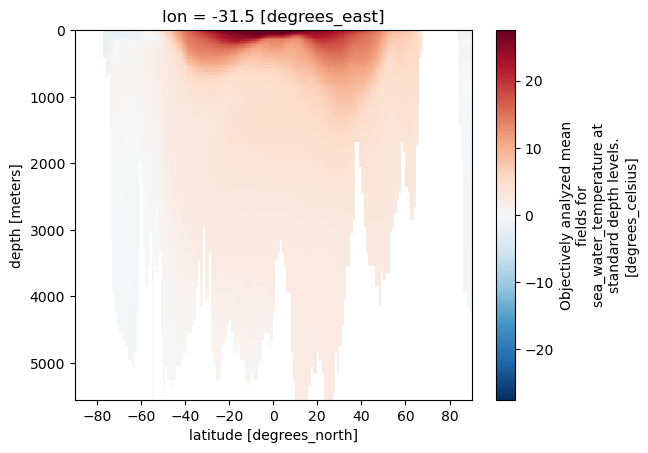

In [47]:
temp.sel(lon=-32, method="nearest").plot(yincrease=False)

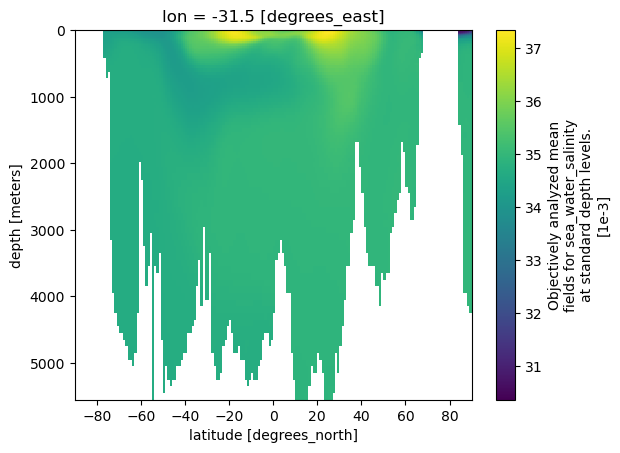

In [48]:
salt.sel(lon=-32, method="nearest").plot(yincrease=False)

### todo: Using the gibbs seawater package (gsw), compute at all latitudes, longitudes, and depths potential density referenced to the surface (sigma0). 
#### <font color=green> </font><br /><font color=green> done

This will first require calculations of absolute salinity and conservative temperature. Remember sigma references some density - 1000 km/m^3.

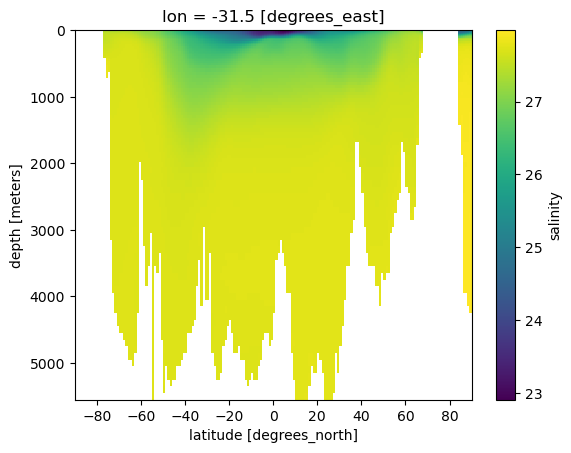

In [49]:
pressure = (gsw.p_from_z(-depth, woa18_data.lat))#.rename({'depth':'pressure'})
# computing pot denisty
potential_density = gsw.pot_rho_t_exact(salt, temp, pressure, 0)-1000

potential_density.sel(lon=-32, method="nearest").plot(yincrease=False)

### todo: Using cartopy produce a global map of T, S and potential density at the surface and at 1000m depth. 
#### <font color=green> </font><br /><font color=green> done

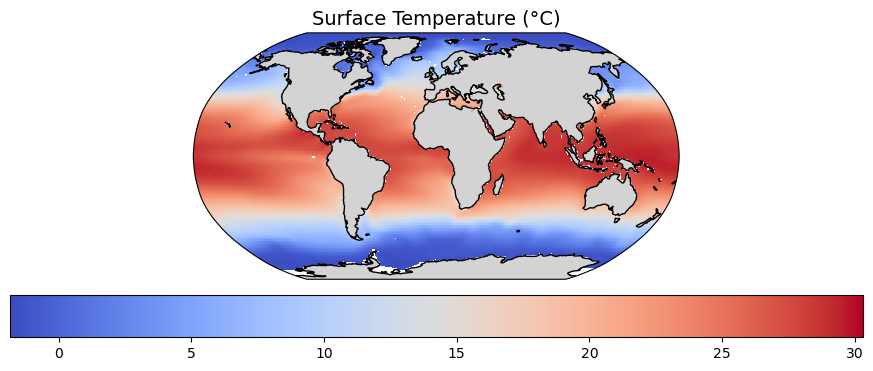

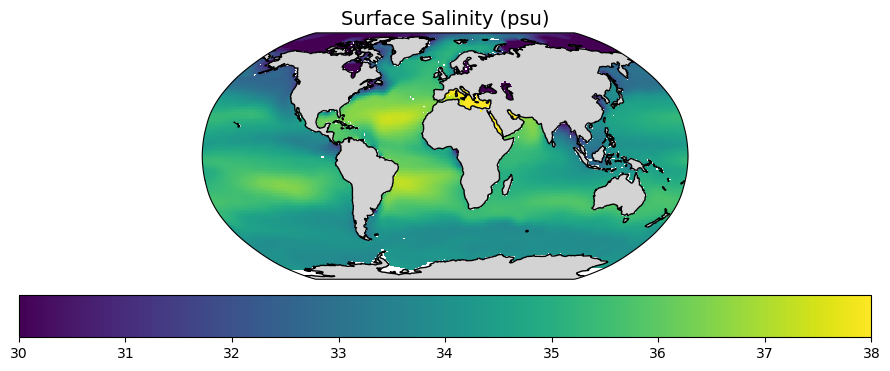

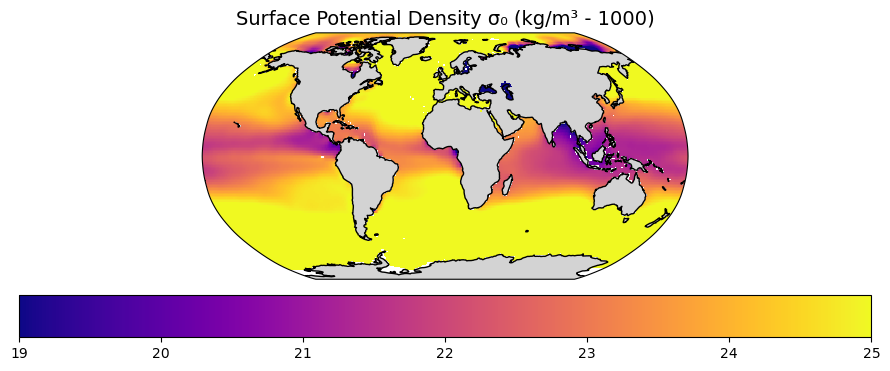

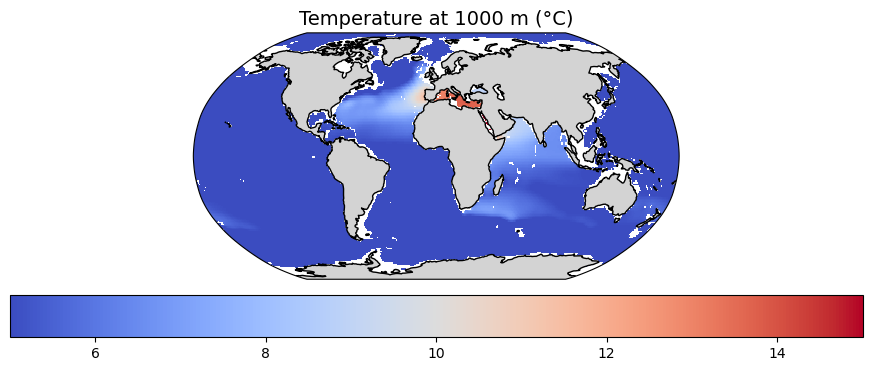

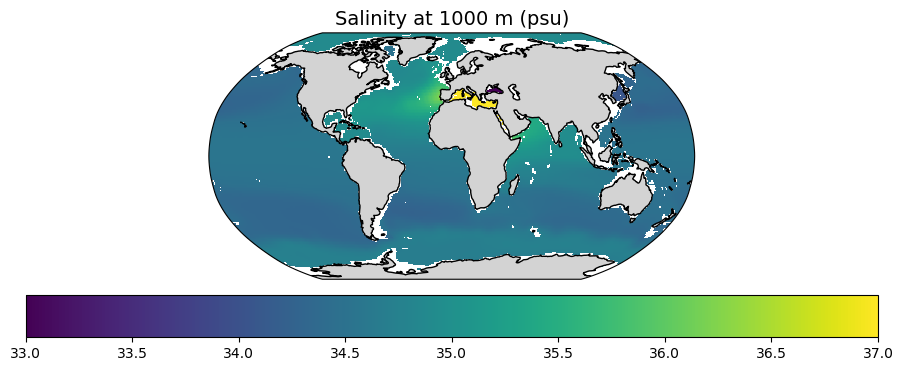

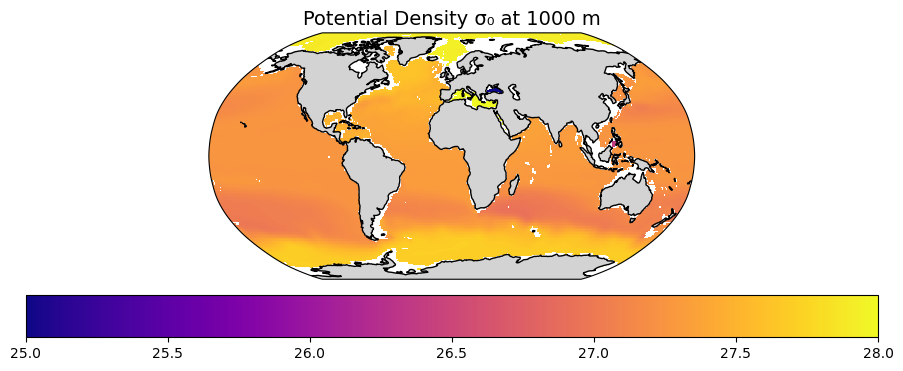

In [50]:
surface = 0
depth_1000 = 1000

# Select nearest depth index
T_surf = temp.sel(depth=surface, method="nearest")
S_surf = salt.sel(depth=surface, method="nearest")
T_1000 = temp.sel(depth=depth_1000, method="nearest")
S_1000 = salt.sel(depth=depth_1000, method="nearest")
D_surf = potential_density.sel(depth=surface, method="nearest")
D_1000 = potential_density.sel(depth=depth_1000, method="nearest")


# ----------------------------------------
# Plotting function
# ----------------------------------------
def plot_global(var, title, cmap, vmin=None, vmax=None):
    plt.figure(figsize=(11,4))
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    mesh = ax.pcolormesh(temp.lon, temp.lat, var,
                         cmap=cmap, vmin=vmin, vmax=vmax,
                         transform=ccrs.PlateCarree())
    plt.title(title, fontsize=14)
    plt.colorbar(mesh, orientation="horizontal", pad=0.05)
    plt.show()

# ----------------------------------------
# Produce maps
# ----------------------------------------

# Surface
plot_global(T_surf, "Surface Temperature (°C)", "coolwarm")
plot_global(S_surf, "Surface Salinity (psu)", "viridis",vmin=30,vmax=38)
plot_global(D_surf, "Surface Potential Density σ₀ (kg/m³ - 1000)", "plasma",vmin=19,vmax=25)

# 1000 m
plot_global(T_1000, "Temperature at 1000 m (°C)", "coolwarm",vmin=5,vmax=15)
plot_global(S_1000, "Salinity at 1000 m (psu)", "viridis",vmin=33,vmax=37)
plot_global(D_1000, "Potential Density σ₀ at 1000 m", "plasma",vmin=25,vmax=28)

### todo: Write a few sentences about the patterns you observe (i.e. why is it warmer or saltier in certain regions?)

Temperature:
The general trend in temp is that the water in the lower latitudes and cooler in the poles; this is from the enregy balance with the solar radiation angle on a sphere leading to a surplus of energy in the low lats and less in the poles. This most evident  in the surface waters; with depth the temp profile becomes more uniform. Key area of gradients with depth are the Mediterranean sea, mMediterranean sea overflow, and the Agulhas retroflection. 

Salinity:
At the surface there are bands of high salinity in the mid to low latitudes. Most likly from higher evaportaion and low rainfall. With the exception of the Mediterranean sea which has very saline waters. Key area of gradients with depth are the Mediterranean sea, mMediterranean sea overflow the poles which are more salty than the mid-lat waters. 

Density:
The lowest denisties are found at the EQ and around the low lats by have varability. At depth the highest denisties are found in the the Mediterranean sea and at the poles.



### todo: Plot a cross section of potential density at 30W longitude (across all latitudes)
#### <font color=green> </font><br /><font color=green> done

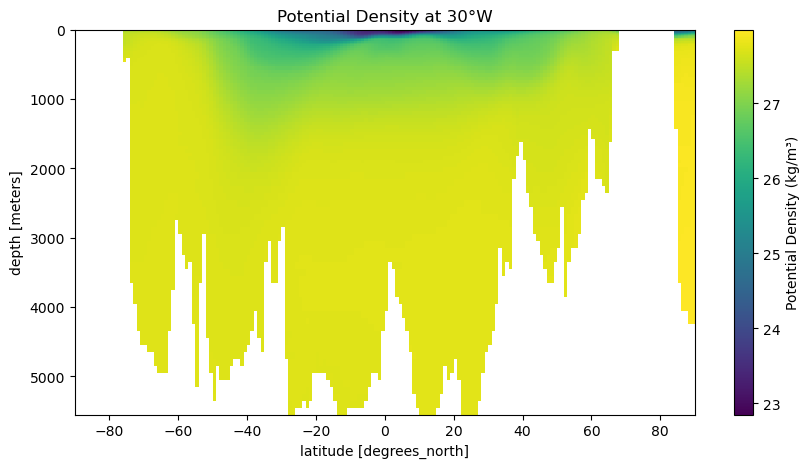

In [51]:
fig, ax = plt.subplots(figsize=(10,5))

p = potential_density.sel(lon=-30, method='nearest').plot(
    yincrease=False,
    ax=ax)
ax.set_title("Potential Density at 30°W")
p.colorbar.set_label("Potential Density (kg/m³)")

### todo: Along this cross-section, estimate and plot horizontal gradients of potential density ($\frac{\partial \sigma_0}{\partial y}$) 

(consider using the centered difference method and ignoring the latitudes for which a centered difference would be incomplete)

Text(0.5, 0, 'Latitude')

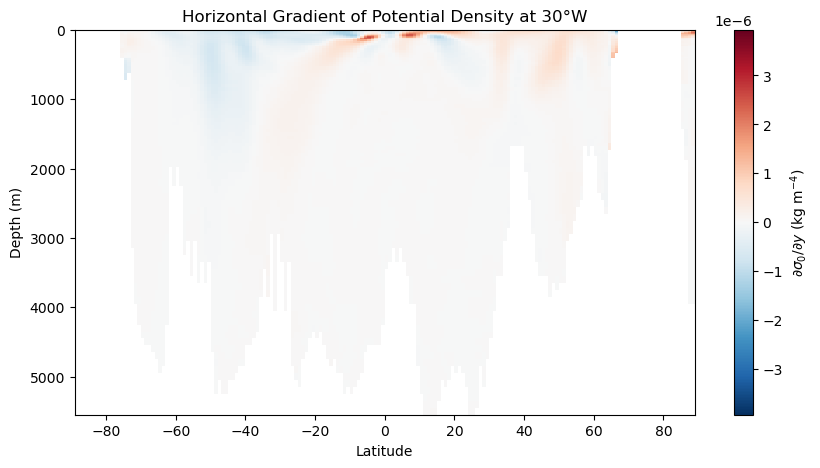

In [52]:
# first lets make a denisty var
rho = potential_density.sel(lon=-32, method="nearest")

# next lets convert lat to meters 
lat = rho.lat
dy = np.deg2rad(lat.diff('lat')) * 6371000  # Earth radius in meters
dy = dy.mean().item()  # y direction in m

# Get the difference from the center (Note: will loose values on end)
# centered difference along the lat dimension
d_rho_dy = (rho.shift(lat=-1) - rho.shift(lat=1)) / (2 * dy)

# remove invalid top/bottom edges
d_rho_dy = d_rho_dy.isel(lat=slice(1, -1))

# now plotting the horizontal gradients
fig, ax = plt.subplots(figsize=(10,5))

p = d_rho_dy.plot(
    yincrease=False,
    ax=ax,
    cmap='RdBu_r',
    cbar_kwargs={'label': r'$\partial \sigma_0 / \partial y$ (kg m$^{-4}$)'}
)

ax.set_title(r"Horizontal Gradient of Potential Density at 30°W")
ax.set_ylabel("Depth (m)")
ax.set_xlabel("Latitude")

### with horizontal gradients of potential density, we can estimate the vertical shear of zonal velocities as

$\Large\frac{\partial u}{\partial z} = \frac{g}{\rho_0 f} \frac{\partial \sigma_0}{\partial y}$

todo: evaluate the right hand side (compute and plot $\frac{\partial u}{\partial z}$)

Text(0, 0.5, 'Depth (m)')

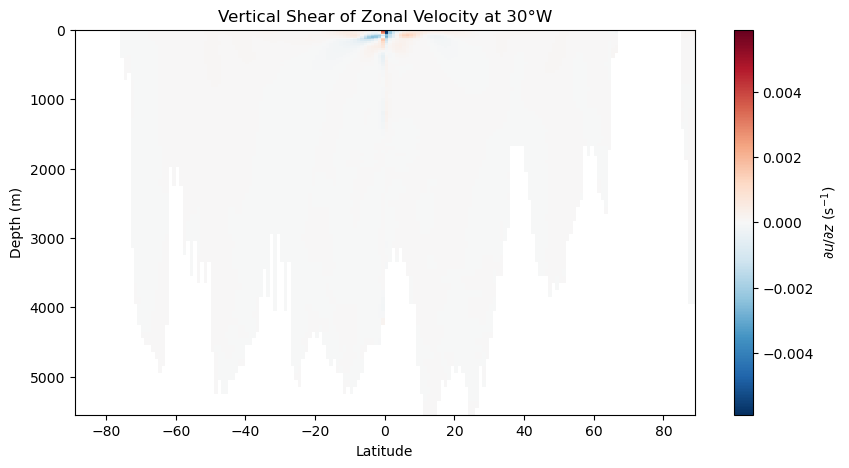

In [53]:
# 1. Compute Coriolis parameter f for each latitude
# constants
Omega = 7.2921e-5          # Earth's rotation rate (s^-1)
g = 9.81                   # gravity (m/s^2)

# Used in Stewart Introduction to Physical Oceanography
rho0 = 1025 # ref den         


lat = d_rho_dy.lat # putting up here again for everthing in one place
f = 2 * Omega * np.sin(np.deg2rad(lat))

# 2. the vertical shera (du/dz) for thermal wind
du_dz = (g / (rho0 * f)) * d_rho_dy
# units s-1

fig, ax = plt.subplots(figsize=(10,5))

p = du_dz.plot(x='lat',
    y='depth',
    yincrease=False,
    cmap='RdBu_r',
    ax=ax,
    cbar_kwargs={'label': r'$\partial u / \partial z$ (s$^{-1}$)'}
)

ax.set_title(r"Vertical Shear of Zonal Velocity at 30°W")
ax.set_xlabel("Latitude")
ax.set_ylabel("Depth (m)")


### todo: select 1000 m as your reference level (or level of no motion) and cumulatively integrate from z = -1000 m to the surface to obtain a profile of zonal velocity $u$

We'll first ignore everything below z = -1000 m and assume $u$ is zero at z = -1000 m. At each latitude, calculate a cumulative vertical  sum of the right hand side, at each level multiplied by $dz$ (the vertical distance separating values), upwards from z = -1000 m ... this approximates a $du$ that when cumulatively summed approximated the total vertical integral.

todo: plot $u$ over this cross-section and across this depth range (spanning all latitudes between z = 0 m and z = -1000 m)

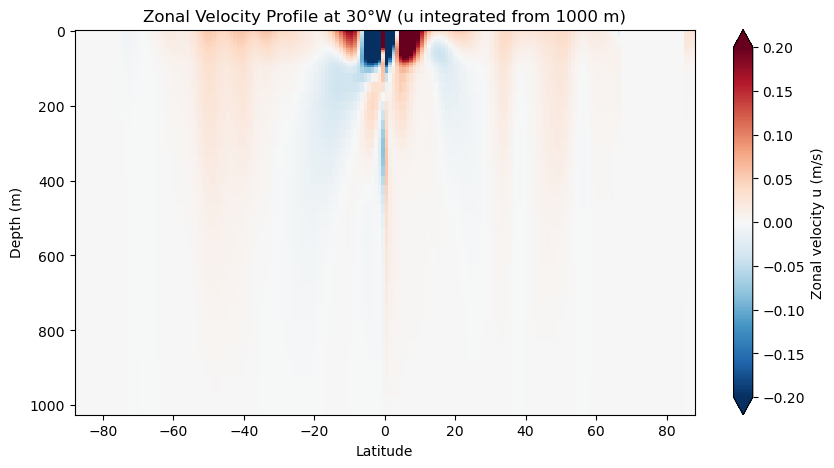

In [34]:
# first slice the first 1000m
deepest_depth = 1000
du_dz_ref = du_dz.sel(depth=slice(0, deepest_depth))

# integration (from 1000 m to 0 m)
du_dz_up = du_dz_ref.isel(depth=slice(None, None, -1))

# vertical spacing
dz = float(np.abs(du_dz_up.depth.diff('depth').mean()))

# cumulative sum for velocty at depth, u=0 at 1000 m
u_up = (du_dz_up * dz).cumsum(dim='depth')

# restore depth order to plot well
u = u_up.isel(depth=slice(None, None, -1))

# drop scalar longitude coordinate 
u = u.drop_vars('lon').transpose('depth', 'lat').compute()

# now to plot
fig, ax = plt.subplots(figsize=(10,5))
p = u.plot(
    x='lat',
    y='depth',
    yincrease=False,
    cmap='RdBu_r',
    cbar_kwargs={'label':'Zonal velocity u (m/s)'},
    ax=ax,vmin=-0.2,vmax=0.2
)
ax.set_title("Zonal Velocity Profile at 30°W (u integrated from 1000 m)")
ax.set_xlabel("Latitude")
ax.set_ylabel("Depth (m)")
plt.show()


### todo: redo the above calculation starting at z = -3000 m and then again at the seafloor

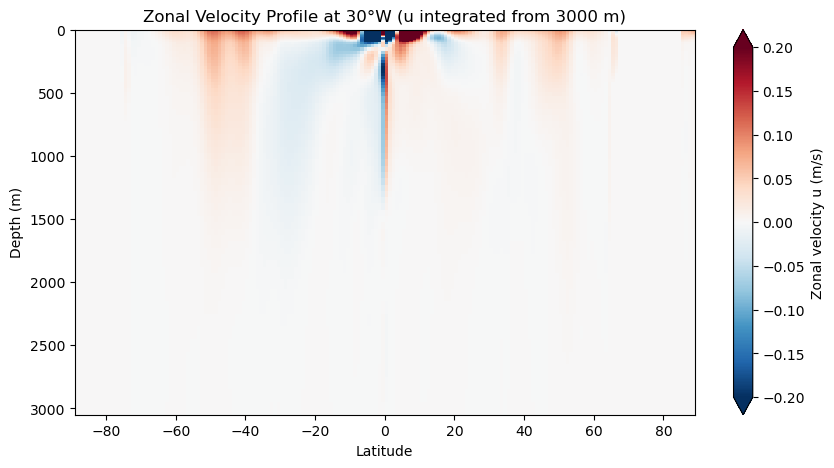

In [58]:
# first slice the first 3000m
#du_dz_ref = du_dz.sel(depth=slice(0, deepest_depth))
ref_level = 3000

du_dz_ref = du_dz.sel(depth=slice(0, ref_level))
# integration (from 1000 m to 0 m)
du_dz_up = du_dz_ref.isel(depth=slice(None, None, -1))

# vertical spacing
dz = float(np.abs(du_dz_up.depth.diff('depth').mean()))

# cumulative sum for velocty at depth, u=0 at 1000 m
u_up = (du_dz_up * dz).cumsum(dim='depth')

# restore depth order to plot well
u = u_up.isel(depth=slice(None, None, -1))

# drop scalar longitude coordinate 
u = u.drop_vars('lon').transpose('depth', 'lat').compute()

# now to plot
fig, ax = plt.subplots(figsize=(10,5))
p = u.plot(
    x='lat',
    y='depth',
    yincrease=False,
    cmap='RdBu_r',
    cbar_kwargs={'label':'Zonal velocity u (m/s)'},
    ax=ax,vmin=-0.2,vmax=0.2
)
ax.set_title("Zonal Velocity Profile at 30°W (u integrated from 3000 m)")
ax.set_xlabel("Latitude")
ax.set_ylabel("Depth (m)")
plt.show()


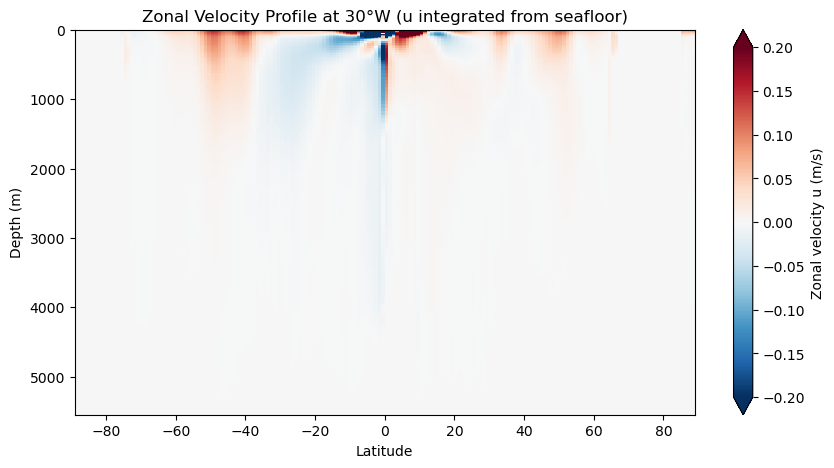

In [59]:
# first slice the first 3000m
deepest_depth = 3000
#du_dz_ref = du_dz.sel(depth=slice(0, deepest_depth))
ref_level = du_dz.depth.max().item()  # bottom-most depth in your array

du_dz_ref = du_dz.sel(depth=slice(0, ref_level))
# integration (from 1000 m to 0 m)
du_dz_up = du_dz_ref.isel(depth=slice(None, None, -1))

# vertical spacing
dz = float(np.abs(du_dz_up.depth.diff('depth').mean()))

# cumulative sum for velocty at depth, u=0 at 1000 m
u_up = (du_dz_up * dz).cumsum(dim='depth')

# restore depth order to plot well
u = u_up.isel(depth=slice(None, None, -1))

# drop scalar longitude coordinate 
u = u.drop_vars('lon').transpose('depth', 'lat').compute()

# now to plot
fig, ax = plt.subplots(figsize=(10,5))
p = u.plot(
    x='lat',
    y='depth',
    yincrease=False,
    cmap='RdBu_r',
    cbar_kwargs={'label':'Zonal velocity u (m/s)'},
    ax=ax,vmin=-0.2,vmax=0.2
)
ax.set_title("Zonal Velocity Profile at 30°W (u integrated from seafloor)")
ax.set_xlabel("Latitude")
ax.set_ylabel("Depth (m)")
plt.show()

### todo: consider how estimates of $u$ over the upper 1000 m change as the refence level deepends. Write a few sentences about these differences, describe the features of $u$ that you observe, and connect them to know currents. 

The features of u extend lower into the water coloumn when the reference u is lower. The lower the ref level the more intense the u values are in the mid-late. 

Key features:
Flow to the west at the EQ which extends down the water coloumn. With flow to the east on both sides of the EQ flow. With depth polesward there is a undercurent which flows to the west. 